In [6]:
import psycopg2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import warnings
from dotenv import load_dotenv
import os

load_dotenv()

HOST = os.getenv("HOST")
DATABASE = os.getenv("DATABASE")
USER = os.getenv("USER")
PASSWORD = os.getenv("PASSWORD")
PORT = os.getenv("PORT")

# Bỏ qua cảnh báo của pandas khi dùng psycopg2 trực tiếp với read_sql
warnings.filterwarnings('ignore', category=UserWarning)

try:
    # 1. Kết nối và lấy dữ liệu
    conn = psycopg2.connect(
        host=HOST,
        database=DATABASE,
        user=USER,
        password=PASSWORD,
        port=PORT  # mặc định là 5432
    )
    
    print("Kết nối database thành công!")

    query = """SELECT * FROM "stroke_data";"""
    df = pd.read_sql(query, con=conn)
    print(f"Đã lấy dữ liệu thành công! Kích thước dữ liệu: {df.shape}")

except Exception as e:
    print("Lỗi khi kết nối hoặc lấy dữ liệu:", e)
    df = None # Gán None nếu lỗi để tránh lỗi ở phần sau

finally:
    # Đảm bảo đóng kết nối sau khi lấy xong data
    if 'conn' in locals() and conn:
        conn.close()
        print("Đã đóng kết nối database an toàn.\n")

Kết nối database thành công!
Đã lấy dữ liệu thành công! Kích thước dữ liệu: (35104, 12)
Đã đóng kết nối database an toàn.



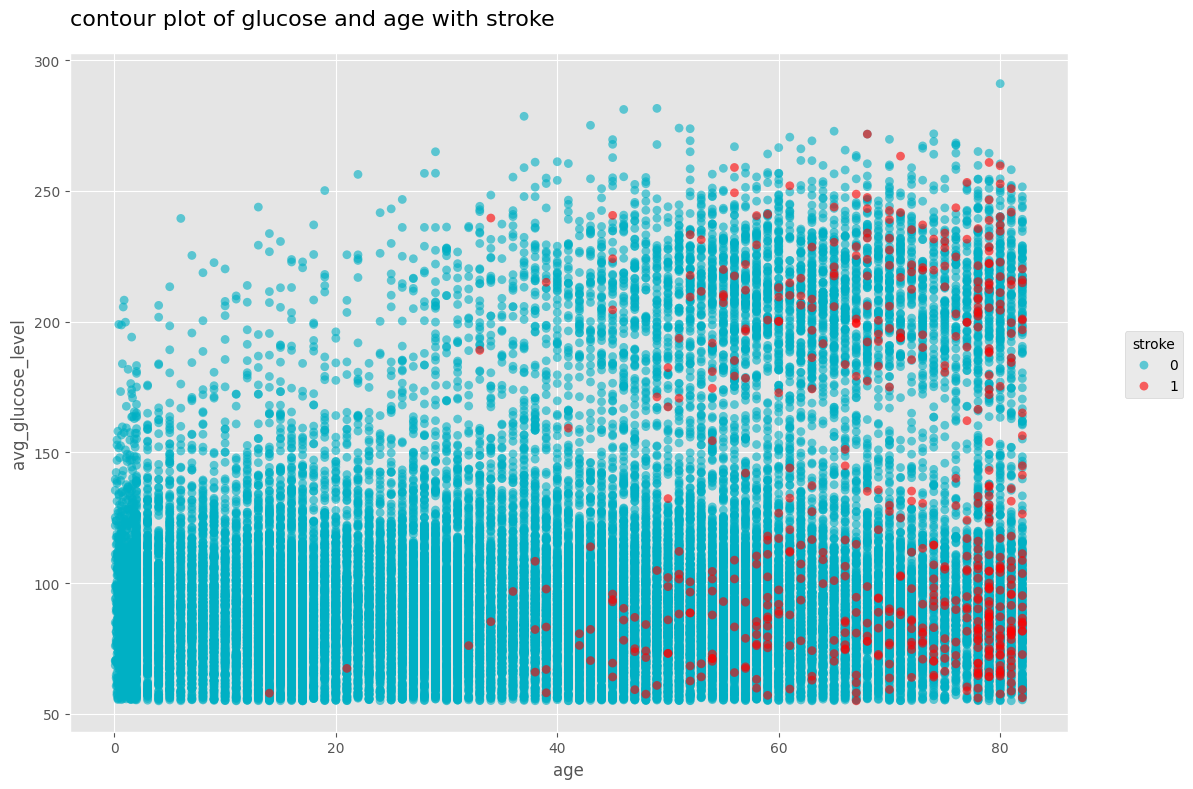

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập style giống ggplot2 (nền xám, lưới trắng)
plt.style.use('ggplot')
plt.figure(figsize=(12, 8))

ax = plt.gca()

# Vẽ xanh trước (stroke=0)
sns.scatterplot(
    data=df[df['stroke'] == 0],
    x='age',
    y='avg_glucose_level',
    color="#00B0C4",
    alpha=0.6,
    edgecolor='none',
    s=40,
    ax=ax,
    label=0
)

# Vẽ đỏ sau (stroke=1) -> đè lên
sns.scatterplot(
    data=df[df['stroke'] == 1],
    x='age',
    y='avg_glucose_level',
    color="#FF0000",
    alpha=0.6,
    edgecolor='none',
    s=40,
    ax=ax,
    label=1
)

# Tùy chỉnh hiển thị
plt.title('contour plot of glucose and age with stroke', fontsize=16, loc='left', pad=20)
plt.xlabel('age', fontsize=12)
plt.ylabel('avg_glucose_level', fontsize=12)

# Legend ra ngoài bên phải
plt.legend(title='stroke', bbox_to_anchor=(1.05, 0.6), loc='upper left')

plt.tight_layout()
plt.show()